# 02 — Choropleth Map & Its Pitfalls
**Part 2 of 7** | GeoMetric Project

## Learning Objectives
- Create normalised choropleths using different classification schemes
- Understand why raw counts must never be mapped directly
- Critique the limitations of choropleth maps

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
import warnings; warnings.filterwarnings("ignore")
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mapclassify as mc
import numpy as np
from scripts.utils.config import PATHS, STYLE
from scripts.utils.map_utils import reproject_gdf, save_figure, add_map_annotations

In [2]:
world = gpd.read_file(PATHS["processed"] / "master_world.gpkg")
world_proj = reproject_gdf(world.copy(), "albers_equal_area")

# Preview available variables
numeric_cols = world.select_dtypes("number").columns.tolist()
print("Available numeric variables:")
for c in numeric_cols:
    pct = world[c].notna().mean() * 100
    print(f"  {c:<30} coverage: {pct:.0f}%")

   Reprojected → albers_equal_area
Available numeric variables:
  pop_est                        coverage: 100%
  gdp_md                         coverage: 100%
  year                           coverage: 97%
  co2_total                      coverage: 97%
  co2_per_capita                 coverage: 97%
  methane                        coverage: 95%
  nitrous_oxide                  coverage: 95%
  total_ghg                      coverage: 95%
  population                     coverage: 97%
  gdp                            coverage: 86%
  energy_per_capita              coverage: 97%
  share_global_co2               coverage: 97%
  cumulative_co2                 coverage: 97%
  population_wb                  coverage: 97%
  pop_final                      coverage: 98%
  co2_per_million                coverage: 97%
  gdp_per_capita                 coverage: 86%
  area_km2                       coverage: 100%
  pop_density                    coverage: 98%


   Saved: raw_vs_normalised_comparison.png  (300 DPI)


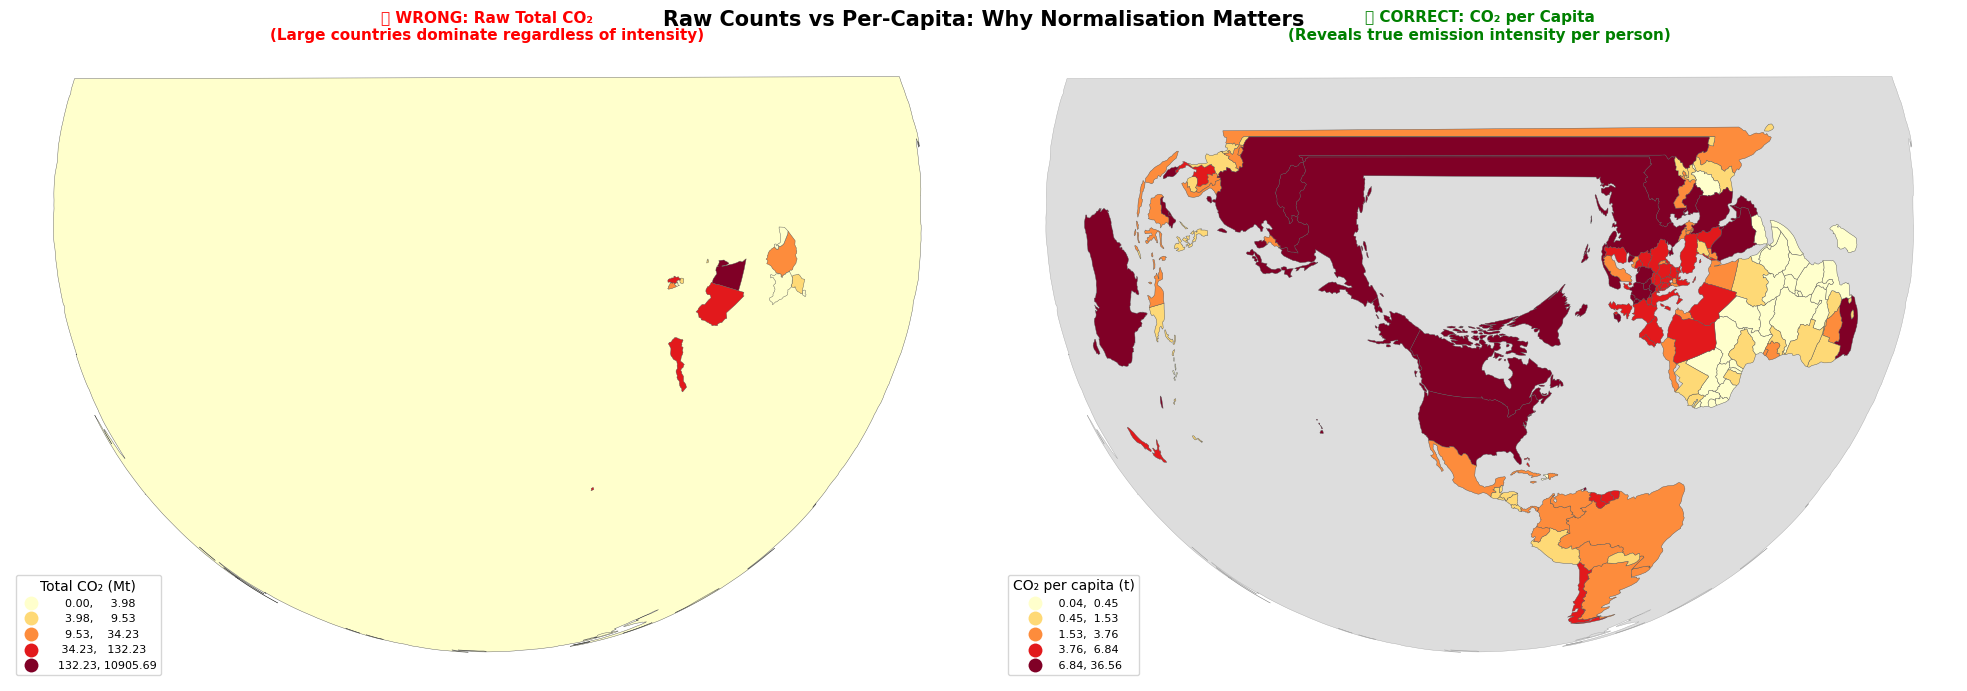

In [3]:
# ── WHY NOT RAW COUNTS: side-by-side demo ──────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle("Raw Counts vs Per-Capita: Why Normalisation Matters",
             fontsize=15, fontweight="bold")

# Map 1: Raw CO2 total (WRONG for choropleth)
world_proj[world_proj["co2_total"].isna()].plot(ax=ax1, color="#ddd", linewidth=0.3, edgecolor="#aaa")
world_proj.dropna(subset=["co2_total"]).plot(
    column="co2_total", ax=ax1, scheme="Quantiles", k=5, cmap="YlOrRd",
    legend=True, legend_kwds={"title":"Total CO₂ (Mt)","loc":"lower left","fontsize":8},
    linewidth=0.3, edgecolor="#555", missing_kwds={"color":"#ddd"}
)
ax1.set_axis_off()
ax1.set_title(" WRONG: Raw Total CO₂\n(Large countries dominate regardless of intensity)",
              color="red", fontsize=11, fontweight="bold")

# Map 2: CO2 per capita (CORRECT)
world_proj[world_proj["co2_per_capita"].isna()].plot(ax=ax2, color="#ddd", linewidth=0.3, edgecolor="#aaa")
world_proj.dropna(subset=["co2_per_capita"]).plot(
    column="co2_per_capita", ax=ax2, scheme="Quantiles", k=5, cmap="YlOrRd",
    legend=True, legend_kwds={"title":"CO₂ per capita (t)","loc":"lower left","fontsize":8},
    linewidth=0.3, edgecolor="#555", missing_kwds={"color":"#ddd"}
)
ax2.set_axis_off()
ax2.set_title(" CORRECT: CO₂ per Capita\n(Reveals true emission intensity per person)",
              color="green", fontsize=11, fontweight="bold")

plt.tight_layout()
save_figure(fig, PATHS["fig_part2"] / "raw_vs_normalised_comparison.png")
plt.show()

   Saved: four_classification_schemes.png  (300 DPI)


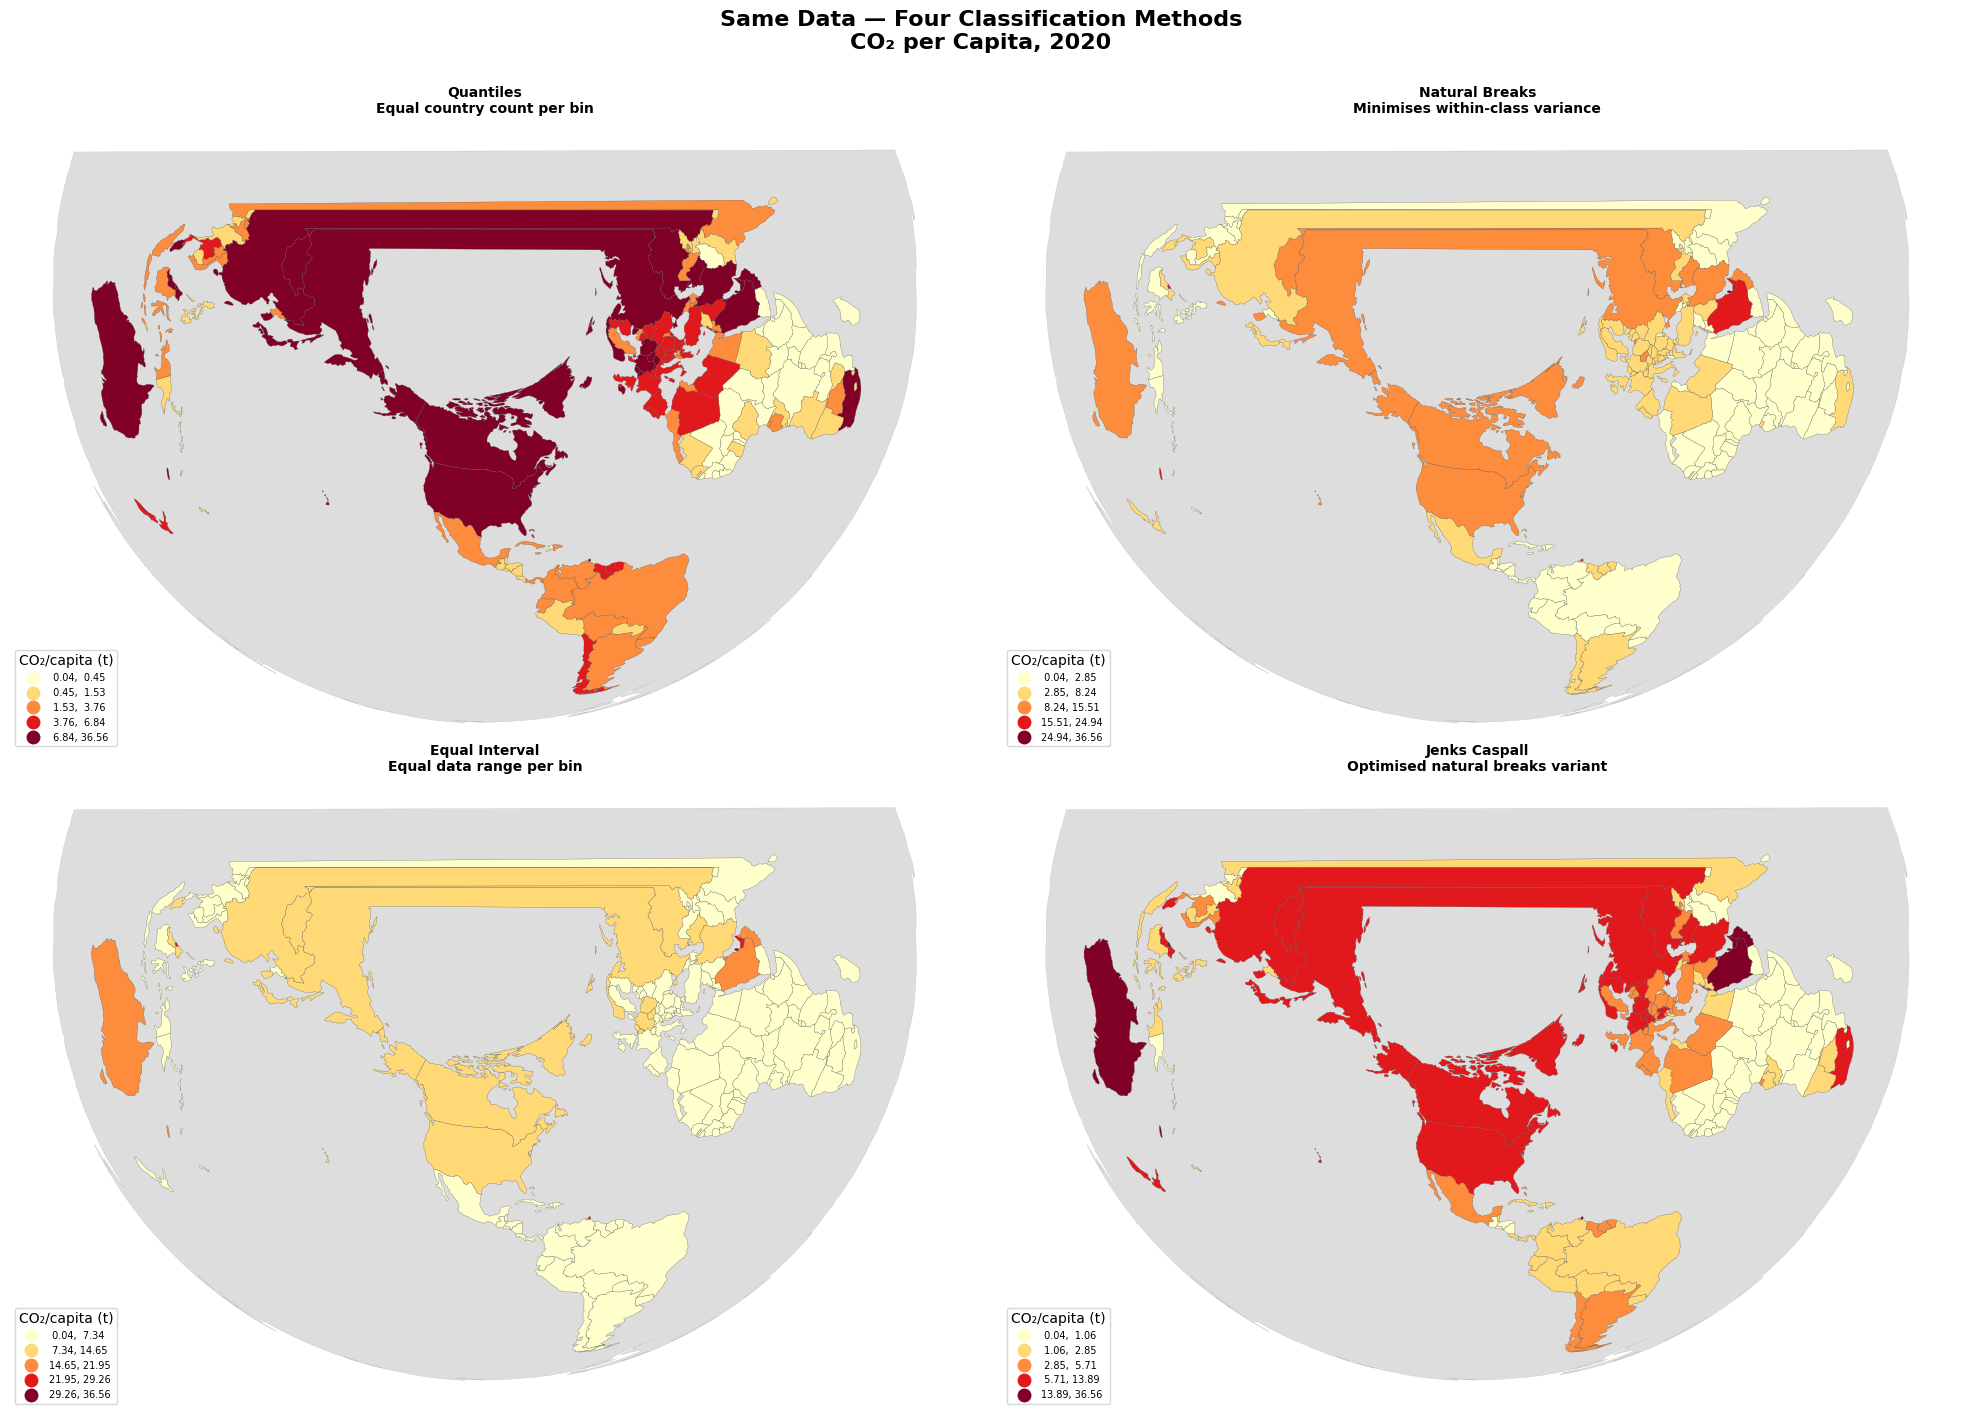

In [4]:
# ── 4 Classification schemes compared ──────────────────────
schemes = [
    ("Quantiles",      "Quantiles",      "Equal country count per bin"),
    ("NaturalBreaks",  "Natural Breaks", "Minimises within-class variance"),
    ("EqualInterval",  "Equal Interval", "Equal data range per bin"),
    ("JenksCaspall",   "Jenks Caspall",  "Optimised natural breaks variant"),
]
data = world_proj["co2_per_capita"].dropna()

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle("Same Data — Four Classification Methods\nCO₂ per Capita, 2020",
             fontsize=16, fontweight="bold", y=1.01)

for ax, (mc_name, label, desc) in zip(axes.flatten(), schemes):
    world_proj[world_proj["co2_per_capita"].isna()].plot(
        ax=ax, color="#ddd", linewidth=0.2, edgecolor="#bbb")
    world_proj.dropna(subset=["co2_per_capita"]).plot(
        column="co2_per_capita", ax=ax, scheme=mc_name, k=5, cmap="YlOrRd",
        legend=True,
        legend_kwds={"title":"CO₂/capita (t)","loc":"lower left","fontsize":7},
        linewidth=0.2, edgecolor="#555",
        missing_kwds={"color":"#ddd","label":"No data"}
    )
    ax.set_axis_off()
    ax.set_facecolor(STYLE["ocean_color"])
    ax.set_title(f"{label}\n{desc}", fontsize=10, fontweight="bold", pad=6)

plt.tight_layout()
save_figure(fig, PATHS["fig_part2"] / "four_classification_schemes.png")
plt.show()

In [5]:
# ── Classification comparison table ────────────────────────
rows = []
for mc_name, label, desc in schemes:
    clf = getattr(mc, mc_name)(data, k=5)
    bins = [round(b, 2) for b in clf.bins]
    rows.append({
        "Method": label,
        "Bin Boundaries": " | ".join(map(str, bins)),
        "ADCM (lower=better)": round(clf.adcm, 3),
        "Description": desc
    })

comparison_df = pd.DataFrame(rows)
comparison_df.to_csv(PATHS["fig_part2"] / "classification_comparison.csv", index=False)

from IPython.display import display
display(comparison_df.style.background_gradient(subset=["ADCM (lower=better)"], cmap="RdYlGn_r"))

,Method,Bin Boundaries,ADCM (lower=better),Description
0,Quantiles,0.45 | 1.53 | 3.76 | 6.84 | 36.56,219.614000,Equal country count per bin
1,Natural Breaks,2.84 | 8.24 | 15.51 | 24.94 | 36.56,171.204000,Minimises within-class variance
2,Equal Interval,7.34 | 14.65 | 21.95 | 29.26 | 36.56,287.151000,Equal data range per bin
3,Jenks Caspall,1.06 | 2.84 | 5.71 | 13.89 | 36.56,145.044000,Optimised natural breaks variant


   Saved: large_area_bias_annotated.png  (300 DPI)


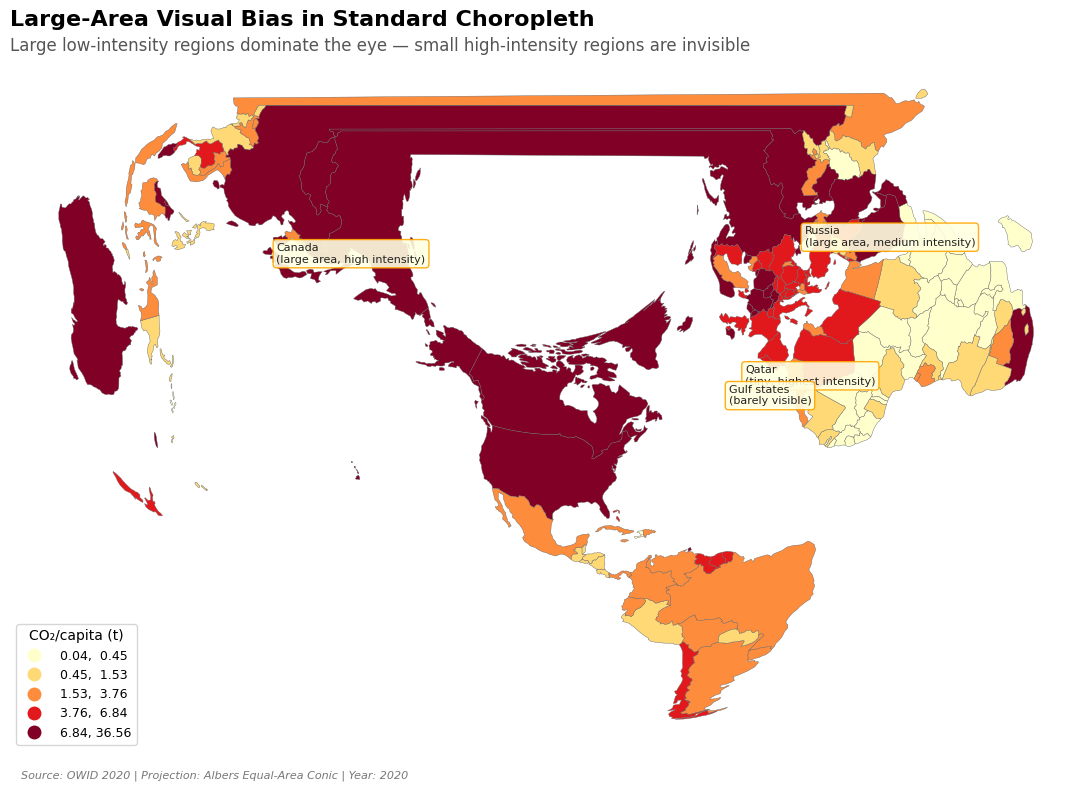

In [6]:
# ── The large-area visual bias ─────────────────────────────
# Annotate Russia, Canada, Australia vs small high-emitters
fig, ax = plt.subplots(figsize=(18, 9))
fig.patch.set_facecolor("white")
ax.set_facecolor(STYLE["ocean_color"])

world_proj.dropna(subset=["co2_per_capita"]).plot(
    column="co2_per_capita", ax=ax, scheme="Quantiles", k=5, cmap="YlOrRd",
    legend=True, legend_kwds={"title":"CO₂/capita (t)","loc":"lower left","fontsize":9},
    linewidth=0.3, edgecolor="#666", missing_kwds={"color":"#ddd"}
)

# Annotate bias countries
annotations = {
    "Russia\n(large area, medium intensity)":  (7_500_000, 7_000_000),
    "Canada\n(large area, high intensity)":    (-8_500_000, 6_500_000),
    "Qatar\n(tiny, highest intensity)":        (5_700_000, 2_800_000),
    "Gulf states\n(barely visible)":           (5_200_000, 2_200_000),
}
for text, xy in annotations.items():
    ax.annotate(text, xy=xy, fontsize=8, color="#222",
                bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="orange", alpha=0.9))

ax.set_axis_off()
add_map_annotations(ax,
    title="Large-Area Visual Bias in Standard Choropleth",
    subtitle="Large low-intensity regions dominate the eye — small high-intensity regions are invisible",
    source="OWID 2020", projection_name="albers_equal_area", year=2020)

save_figure(fig, PATHS["fig_part2"] / "large_area_bias_annotated.png")
plt.show()

## Critique Summary

**Why raw counts must not be used on choropleths:**
- A choropleth fills the entire region polygon, implying the value is *uniformly distributed*
- Raw count = total volume (e.g. 10 billion tonnes), which is dominated by country size
- Per-capita normalisation reveals *intensity* — the meaningful policy variable

**How classification method changes the story:**
- Quantiles: always 5 equal-sized groups → good contrast, but arbitrary cut-points
- Natural Breaks: statistically meaningful cuts → harder to compare across maps
- Equal Interval: intuitive but breaks down with skewed data (outliers steal a whole class)

**The large-area bias:**
Qatar emits ~30t CO₂/capita (world's highest). Russia emits ~11t (significant but not extreme).
On a standard map Russia appears dominant simply because it covers 11% of land area.